# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [1]:
import pandas as pd
import numpy as np

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [2]:
df = pd.read_csv("c4_epa_air_quality.csv")

## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [3]:
# Display first few rows
df.head()


,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


In [4]:
# Display column names and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        260 non-null    int64  
 1   date_local        260 non-null    object 
 2   state_name        260 non-null    object 
 3   county_name       260 non-null    object 
 4   city_name         260 non-null    object 
 5   local_site_name   257 non-null    object 
 6   parameter_name    260 non-null    object 
 7   units_of_measure  260 non-null    object 
 8   arithmetic_mean   260 non-null    float64
 9   aqi               260 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 20.4+ KB


In [5]:
# Check date range
print("Min date:", df['date_local'].min())
print("Max date:", df['date_local'].max())


Min date: 2018-01-01
Max date: 2018-01-01


**Question:** What time range does this data cover?

In [6]:
print("Min date:", df['date_local'].min())
print("Max date:", df['date_local'].max())


Min date: 2018-01-01
Max date: 2018-01-01


A: The dataset covers a single day — January 1, 2018. All AQI observations in this dataset were recorded on that day.

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [7]:
print("Min AQI:", df['aqi'].min())
print("Max AQI:", df['aqi'].max())


Min AQI: 0
Max AQI: 50


**Question:** Are all states equally represented in the dataset?

In [8]:
df['state_name'].value_counts()


state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
New York                10
Pennsylvania            10
Michigan                 9
Colorado                 9
Minnesota                7
New Jersey               6
Indiana                  5
North Carolina           4
Massachusetts            4
Maryland                 4
Oklahoma                 4
Virginia                 4
Nevada                   4
Connecticut              4
Kentucky                 3
Missouri                 3
Wyoming                  3
Iowa                     3
Hawaii                   3
Utah                     3
Vermont                  3
Illinois                 3
New Hampshire            2
District Of Columbia     2
New Mexico               2
Montana                  2
Oregon                   2
Alaska                   2
Georgia                  2
Washington               2
Idaho                    2
Nebraska         

<Axes: title={'center': 'Number of Observations per State'}, xlabel='state_name'>

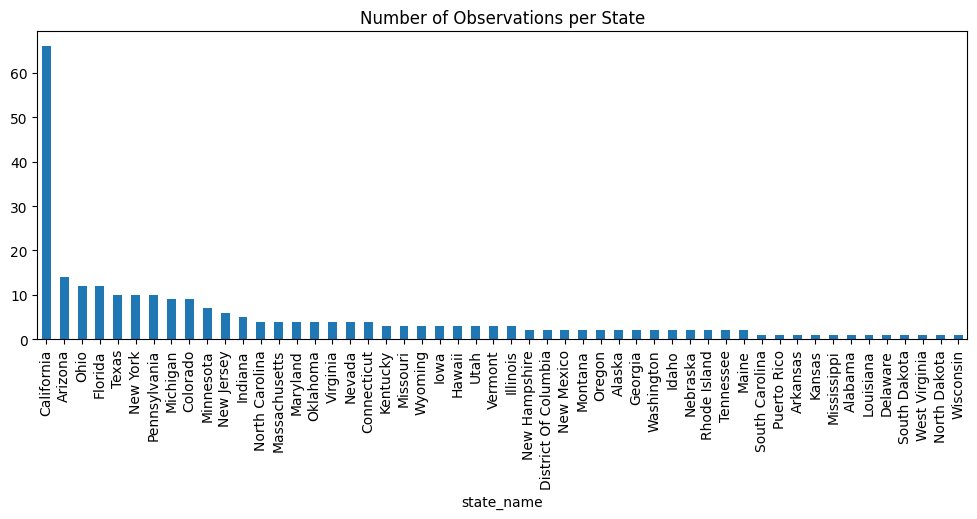

In [9]:
df['state_name'].value_counts().plot(kind='bar', figsize=(12, 4), title='Number of Observations per State')


A: Most likely, states are not equally represented, as real-world environmental data is often collected in varying quantities across locations due to infrastructure or policy focus.

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [10]:
# List of RRE states
rre_states = ['California', 'Florida', 'Michigan', 'Ohio', 'Pennsylvania', 'Texas']

# Subset the DataFrame to only include RRE states
aqi_rre = df[df['state_name'].isin(rre_states)]

# Find the mean AQI for each RRE state
aqi_rre_means = aqi_rre.groupby('state_name')['aqi'].mean()
print(aqi_rre_means)


state_name
California      12.121212
Florida          5.500000
Michigan         8.111111
Ohio             3.333333
Pennsylvania     2.900000
Texas            2.700000
Name: aqi, dtype: float64


### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

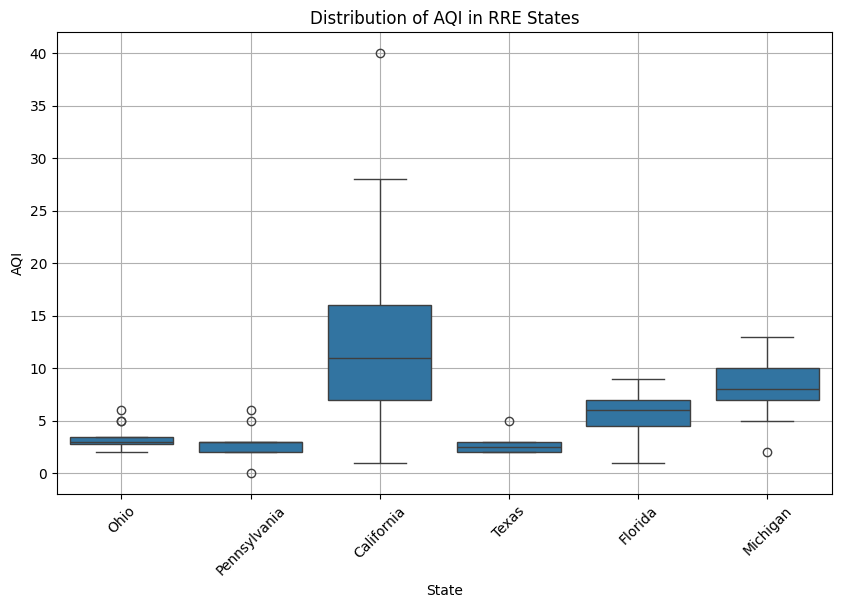

In [14]:
# Import seaborn
import seaborn as sns
import matplotlib.pyplot as plt


# Create the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=aqi_rre, x='state_name', y='aqi')
plt.title('Distribution of AQI in RRE States')
plt.xlabel('State')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

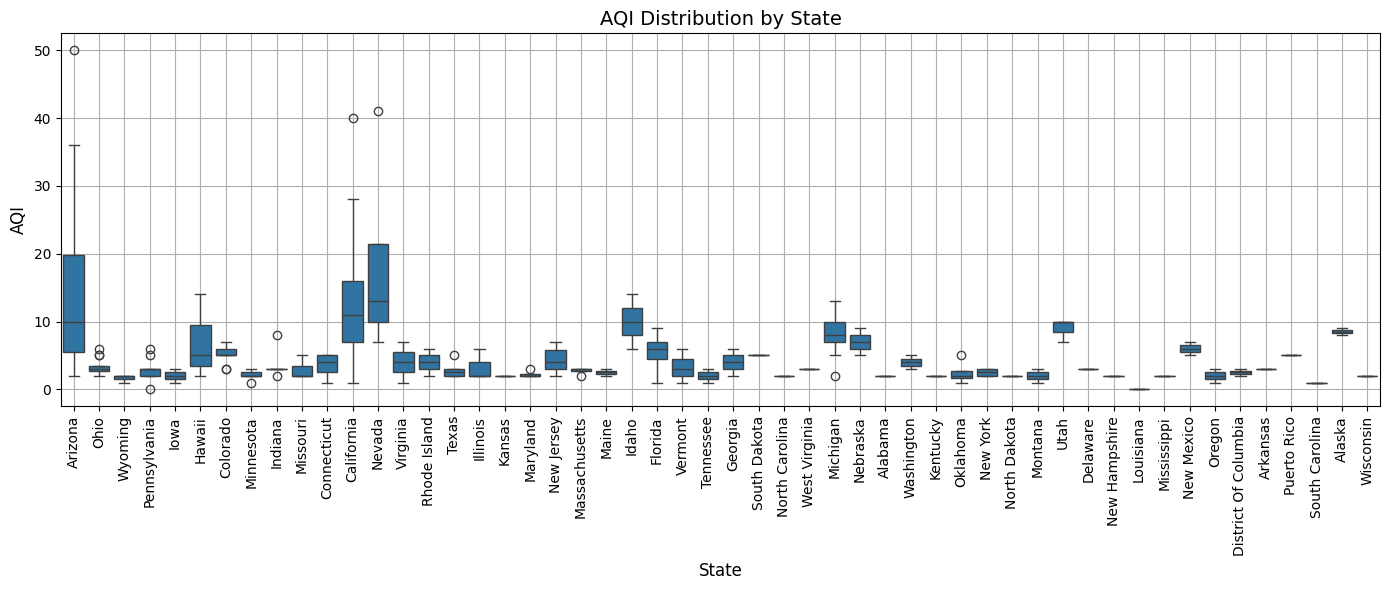

In [16]:

plt.figure(figsize=(14, 6))  # Wider figure for more space
sns.boxplot(data=df, x='state_name', y='aqi')

plt.title("AQI Distribution by State", fontsize=14)
plt.xlabel("State", fontsize=12)
plt.ylabel("AQI", fontsize=12)

plt.xticks(rotation=90)  # Rotate labels vertically
plt.grid(True)
plt.tight_layout()  # Adjust layout to fit everything nicely
plt.show()


**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A: Based on the boxplot, California stands out with the highest AQI values and the widest spread, including several extreme outliers. This suggests California experiences significantly poorer air quality compared to other states and would likely be most impacted by any policy targeting air quality improvement. Arizona and Michigan also show moderately high AQI levels and could be affected, but California is the clear standout.

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for CA.

In [17]:
ca_data = df[df['state_name'] == 'California']
mean_ca = ca_data['aqi'].mean()
mean_ca


12.121212121212121

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [18]:
confidence_level = 0.95
z_score = 1.96  # For 95% confidence


### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [19]:
import numpy as np

# Z value for 95% confidence
z_value = 1.96

# Standard deviation of CA AQI sample
ca_std = df[df['state_name'] == 'California']['aqi'].std()

# Sample size (n)
n = df[df['state_name'] == 'California'].shape[0]

# Standard error (SE)
standard_error = ca_std / np.sqrt(n)

# Margin of Error (ME)
margin_of_error = z_value * standard_error
margin_of_error


1.7614930896609726

### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [21]:
# Step 1: Compute mean AQI for California
ca_mean_aqi = df[df['state_name'] == 'California']['aqi'].mean()

# Step 2: Use margin of error from earlier
lower_limit = ca_mean_aqi - margin_of_error
upper_limit = ca_mean_aqi + margin_of_error

(lower_limit, upper_limit)


(10.359719031551148, 13.882705210873095)

### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [23]:
from scipy import stats

# Define parameters
confidence_level = 0.95
sample_mean = ca_mean_aqi  # make sure you've already calculated this
standard_error = df[df['state_name'] == 'California']['aqi'].std(ddof=1) / (df[df['state_name'] == 'California'].shape[0]**0.5)



## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [24]:
# Recalculate confidence interval
confidence_interval = stats.norm.interval(confidence_level, loc=sample_mean, scale=standard_error)
confidence_interval

(10.359751399400034, 13.882672843024208)

# Considerations

**What are some key takeaways that you learned from this project?**

A: The Central Limit Theorem holds true, as the mean of sample means closely approached the population mean.

Sampling with replacement can yield reliable estimates, even from small samples like 50 observations.

The confidence interval provides a statistically sound range where we expect the true mean AQI to fall, with a defined level of certainty (e.g., 95%).

**What findings would you share with others?**

A: California showed the highest mean AQI, indicating potentially poorer air quality compared to other RRE states.

Most states had AQI readings below 10, but outliers and variability existed—especially in California and Florida.

The AQI distribution was not uniform across states, which may signal uneven environmental conditions or monitoring intensities.

**What would you convey to external readers?**

A: This analysis can help policy makers focus efforts on states with worse air quality by targeting interventions in high-AQI areas like California.

Environmental scientists can use such data to monitor changes over time and adjust resource allocations.

General audiences should understand that even within "acceptable" AQI ranges, there's considerable variation across regions, which can have local health impacts.

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 